# Young and sparse evidence

This notebook implements NB14 from `steady-vault-plan-01.md`. It keeps the
NB12 P1+D1 selection parent frozen and tests only the evidence-cap policy for
the selected basket:

* **E0**: 5% individual cap for provisional names and a 20% aggregate
  provisional sleeve;
* **E1**: 2% individual cap for provisional names and the same aggregate
  sleeve; and
* **E2**: a provisional individual cap that increases from 2% at two observed
  intervals to 10% at twenty intervals, with the same aggregate sleeve.

Names with at least 30 days of available history, at least four measured
weekly outcomes and complete growth/downside inputs are treated as fully
evidenced for this experiment. The flags are calculated from the causal NB12
row at each decision date. A missing input is provisional; it is never
replaced by a zero risk estimate. The notebook reports both the A0b snapshot
allowlist and the full research panel, daily and hypothetical weekly-sampled
metrics, residual cash and StratWise coverage. NAV forward-fill is used only
for valuation between observed marks. There are no invented fees, slippage or
liquidation assumptions.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd() / "scratchpad/hyperliquid-ic" if (Path.cwd() / "scratchpad/hyperliquid-ic").exists() else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
REWRITE = PROJECT_DIR / "_artifacts-rewrite"
NB12 = PROJECT_DIR / "_artifacts-downside-stress"
OUT = PROJECT_DIR / "_artifacts-young-sparse"
OUT.mkdir(exist_ok=True)

PERIODS = {
    "hyper_ai": (pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-08")),
    "full": (pd.Timestamp("2025-09-13"), pd.Timestamp("2026-09-12")),
}
INITIAL_CASH = 150_000.0
TARGET_DEPLOYMENT = 0.98
MAX_WEIGHT = 0.20
MAX_TVL_FRACTION = 0.33
PROVISIONAL_SLEEVE = 0.20
E0_PROVISIONAL_CAP = 0.05
E1_PROVISIONAL_CAP = 0.02
E2_LOW_CAP = 0.02
E2_HIGH_CAP = 0.10
E2_LOW_INTERVALS = 2
E2_HIGH_INTERVALS = 20
EXECUTION_EVERY_DAYS = 2
STRATWISE = "0x0ff219ac20596b457558341bc410bc7a08a1394c"

OBS = pd.read_parquet(REWRITE / "observations.parquet")
OBS["address"] = OBS.address.astype(str).str.lower()
OBS["timestamp"] = pd.to_datetime(OBS.timestamp)
OBS = OBS[OBS.is_fresh & OBS.share_price.gt(0)].sort_values(["address", "timestamp"])

METADATA = pd.read_csv(REWRITE / "vault-metadata.csv")
METADATA["address"] = METADATA.address.astype(str).str.lower()
METADATA = METADATA.drop_duplicates("address").set_index("address")

# Keep NB12's point-in-time risk table in the manifest.  The D1 selection
# files below are the frozen causal admission decisions consumed by this
# replay; retaining the source table makes that boundary explicit.
POINT_IN_TIME = pd.read_parquet(NB12 / "point_in_time-risk-signals.parquet")
POINT_IN_TIME["date"] = pd.to_datetime(POINT_IN_TIME.date).dt.normalize()
POINT_IN_TIME["address"] = POINT_IN_TIME.address.astype(str).str.lower()

UNIVERSE_CACHE = Path("/Users/moo/.cache/indicators/vault-universe-tvl7500-top9999-age0.0-sort1Y-curbbf10d84.json")
universe_json = json.loads(UNIVERSE_CACHE.read_text())
universe_items = universe_json.get("vaults", universe_json) if isinstance(universe_json, dict) else universe_json
A0B_ALLOWLIST = {str(item["address"]).lower() for item in universe_items if "address" in item}
A0B_ALLOWLIST.discard("0x5290ab34acb59cfe1371baa5782eba14433d308f")

SIGNAL_COLUMNS = [
    "date", "address", "selected", "selection_rank", "qualified", "tvl_current",
    "estimated_net_growth", "annualised_downside", "available_history_days",
    "observation_count", "weekly_outcomes", "history_observed_intervals",
    "last_interval_days", "last_interval_days_risk", "is_sparse_prediction",
    "d1", "d1_missing", "parent_qualified", "parent_selection_order",
]
SELECTIONS = {}
for universe_name, addresses in {"full_panel": set(), "a0b_allowlist": A0B_ALLOWLIST}.items():
    path = NB12 / f"selection-{universe_name}-D1.parquet"
    frame = pd.read_parquet(path)
    frame["date"] = pd.to_datetime(frame.date).dt.normalize()
    frame["address"] = frame.address.astype(str).str.lower()
    if universe_name == "full_panel":
        addresses = set(frame.address.unique())
    frame = frame[frame.address.isin(addresses)].copy()
    frame = frame[[column for column in SIGNAL_COLUMNS if column in frame.columns]].copy()
    frame = frame[frame.date.between(PERIODS["full"][0], PERIODS["full"][1])]
    if frame.duplicated(["date", "address"]).any():
        raise AssertionError(f"duplicate causal selection rows in {universe_name}")
    SELECTIONS[universe_name] = frame

print({"observations": OBS.shape, "point_in_time_risk_signals": POINT_IN_TIME.shape, "universes": {name: int(frame.address.nunique()) for name, frame in SELECTIONS.items()}, "selected_d1_rows": {name: int(frame.selected.fillna(False).sum()) for name, frame in SELECTIONS.items()}})


{'observations': (487738, 9), 'point_in_time_risk_signals': (104618, 253), 'universes': {'full_panel': 529, 'a0b_allowlist': 335}, 'selected_d1_rows': {'full_panel': 2874, 'a0b_allowlist': 2192}}


## Causal evidence classification

The provisional flag is deliberately a coverage flag, not a prediction of
quality. `available_history_days` is the observed span at the decision date;
it is used instead of metadata age. `weekly_outcomes` is the cadence-matched
count generated by NB11. A sparse last interval or sparse-prediction marker is
also reported because a nominal span can conceal a thin path. These rules let
young and weekly vaults remain visible while preventing incomplete evidence
from receiving a mature allocation cap.


In [2]:
def finite(value):
    return pd.notna(value) and np.isfinite(float(value))


def evidence_flags(frame):
    output = frame.copy()
    age = pd.to_numeric(output.get("available_history_days"), errors="coerce")
    weekly = pd.to_numeric(output.get("weekly_outcomes"), errors="coerce")
    intervals = pd.to_numeric(output.get("history_observed_intervals"), errors="coerce")
    last_gap = pd.to_numeric(output.get("last_interval_days_risk", output.get("last_interval_days")), errors="coerce")
    growth_missing = ~pd.to_numeric(output.estimated_net_growth, errors="coerce").map(np.isfinite)
    downside_missing = ~pd.to_numeric(output.annualised_downside, errors="coerce").map(np.isfinite)
    weekly_missing = weekly.isna()
    output["young_flag"] = age.isna() | age.lt(30.0)
    output["sparse_weekly_flag"] = weekly_missing | weekly.lt(4.0)
    output["sparse_cadence_flag"] = last_gap.gt(8.0).fillna(True) | output.is_sparse_prediction.fillna(True)
    output["missing_consistency_flag"] = weekly_missing | growth_missing | downside_missing
    output["provisional"] = output[["young_flag", "sparse_weekly_flag", "sparse_cadence_flag", "missing_consistency_flag"]].any(axis=1)
    output["evidence_reason"] = np.select(
        [output.young_flag & output.sparse_weekly_flag, output.young_flag, output.sparse_weekly_flag, output.sparse_cadence_flag, output.missing_consistency_flag],
        ["young_and_sparse_weekly", "young_history", "fewer_than_four_weekly_outcomes", "sparse_cadence", "missing_growth_downside_or_consistency"],
        default="fully_evidenced",
    )
    output["evidence_interval_count"] = intervals.fillna(0.0).clip(lower=0.0)
    return output


for universe_name in SELECTIONS:
    SELECTIONS[universe_name] = evidence_flags(SELECTIONS[universe_name])

summary_rows = []
for universe_name, frame in SELECTIONS.items():
    selected = frame[frame.selected.fillna(False)]
    for reason, group in selected.groupby("evidence_reason", dropna=False):
        summary_rows.append({"universe": universe_name, "evidence_reason": reason, "rows": len(group), "dates": int(group.date.nunique()), "addresses": int(group.address.nunique())})
    summary_rows.append({"universe": universe_name, "evidence_reason": "all_selected", "rows": len(selected), "dates": int(selected.date.nunique()), "addresses": int(selected.address.nunique())})
evidence_summary = pd.DataFrame(summary_rows)
evidence_summary.to_csv(OUT / "evidence-summary.csv", index=False)
display(evidence_summary)

age_cadence_rows = []
for universe_name, frame in SELECTIONS.items():
    view = frame.copy()
    age = pd.to_numeric(view.available_history_days, errors="coerce")
    gap = pd.to_numeric(view.last_interval_days_risk, errors="coerce")
    view["age_bucket"] = pd.cut(age, [-np.inf, 14, 30, 60, np.inf], labels=["0-14d", "15-30d", "31-60d", "61d+"])
    view["cadence_bucket"] = np.select([gap.le(2), gap.le(8)], ["daily_like", "weekly_like"], default="sparse_or_unknown")
    for (age_bucket, cadence_bucket), group in view.groupby(["age_bucket", "cadence_bucket"], observed=False, dropna=False):
        selected = group[group.selected.fillna(False)]
        age_cadence_rows.append({
            "universe": universe_name,
            "age_bucket": str(age_bucket),
            "cadence_bucket": cadence_bucket,
            "rows": len(group),
            "addresses": int(group.address.nunique()),
            "selected_rows": len(selected),
            "selected_addresses": int(selected.address.nunique()),
            "provisional_rows": int(group.provisional.sum()),
            "selected_provisional_rows": int(selected.provisional.sum()),
        })
age_cadence_summary = pd.DataFrame(age_cadence_rows)
age_cadence_summary.to_csv(OUT / "age-cadence-coverage.csv", index=False)
display(age_cadence_summary)


,universe,evidence_reason,rows,dates,addresses
0,full_panel,fully_evidenced,2873,226,111
1,full_panel,sparse_cadence,1,1,1
2,full_panel,all_selected,2874,226,111
3,a0b_allowlist,fully_evidenced,2192,223,73
4,a0b_allowlist,all_selected,2192,223,73


,universe,age_bucket,cadence_bucket,rows,addresses,selected_rows,selected_addresses,provisional_rows,selected_provisional_rows
0,full_panel,0-14d,daily_like,1975,218,0,0,1975,0
1,full_panel,0-14d,weekly_like,184,22,0,0,184,0
2,full_panel,15-30d,daily_like,3336,218,0,0,3304,0
3,full_panel,15-30d,weekly_like,182,17,0,0,182,0
4,full_panel,31-60d,daily_like,5575,237,187,18,1661,0
5,full_panel,31-60d,weekly_like,434,37,0,0,358,0
6,full_panel,61d+,daily_like,72070,439,2687,105,15273,1
7,full_panel,61d+,sparse_or_unknown,56,10,0,0,56,0
8,full_panel,61d+,weekly_like,3269,209,0,0,2614,0
9,a0b_allowlist,0-14d,daily_like,1177,130,0,0,1177,0


## Capped equal-weight allocation

The frozen parent supplies the equal-weight requested allocation. Evidence
caps are applied before the existing 20% equity and 33% TVL caps. The
provisional sleeve is then capped at 20% of equity. Clipped dollars remain in
cash; they are never silently redistributed. A held blocked position is kept
as an accounting position, following the existing replay convention. The
accepted allocation table records which cap bound and its evidence fields.


In [3]:
def evidence_cap(row, arm):
    if not bool(row.provisional):
        return MAX_WEIGHT
    if arm == "E0":
        return E0_PROVISIONAL_CAP
    if arm == "E1":
        return E1_PROVISIONAL_CAP
    if arm == "E2":
        count = float(row.evidence_interval_count)
        progress = np.clip((count - E2_LOW_INTERVALS) / (E2_HIGH_INTERVALS - E2_LOW_INTERVALS), 0.0, 1.0)
        return float(E2_LOW_CAP + progress * (E2_HIGH_CAP - E2_LOW_CAP))
    raise ValueError(arm)


def allocation_for(day, equity, arm, last_prices, blocked):
    chosen = day[day.selected.fillna(False)].copy()
    if chosen.empty:
        return pd.DataFrame(columns=["address", "requested_dollars", "accepted_dollars", "cap_dollars"])
    requested_weight = TARGET_DEPLOYMENT / len(chosen)
    rows = []
    for item in chosen.itertuples(index=False):
        address = item.address
        tvl = float(item.tvl_current) if finite(item.tvl_current) else 0.0
        cap_weight = min(MAX_WEIGHT, evidence_cap(item, arm))
        cap_dollars = min(equity * cap_weight, max(tvl, 0.0) * MAX_TVL_FRACTION)
        requested = equity * requested_weight
        accepted = min(max(requested, 0.0), max(cap_dollars, 0.0)) if address in last_prices else 0.0
        rows.append({
            "address": address, "date": item.date, "requested_weight": requested_weight,
            "requested_dollars": requested, "accepted_dollars": accepted,
            "cap_dollars": cap_dollars, "evidence_cap_weight": cap_weight,
            "provisional": bool(item.provisional), "evidence_reason": item.evidence_reason,
            "young_flag": bool(item.young_flag), "sparse_weekly_flag": bool(item.sparse_weekly_flag),
            "evidence_interval_count": item.evidence_interval_count,
            "tvl_current": item.tvl_current, "annualised_downside": item.annualised_downside,
            "estimated_net_growth": item.estimated_net_growth,
        })
    allocations = pd.DataFrame(rows)
    provisional_total = allocations.loc[allocations.provisional, "accepted_dollars"].sum()
    sleeve_cap = equity * PROVISIONAL_SLEEVE
    if provisional_total > sleeve_cap > 0:
        factor = sleeve_cap / provisional_total
        allocations.loc[allocations.provisional, "accepted_dollars"] *= factor
        allocations["aggregate_provisional_cap_binding"] = allocations.provisional
    else:
        allocations["aggregate_provisional_cap_binding"] = False
    allocations["individual_cap_binding"] = allocations.accepted_dollars + 1e-8 < allocations.requested_dollars
    allocations["accepted_weight"] = allocations.accepted_dollars / equity if equity > 0 else np.nan
    allocations["accepted_tvl_fraction"] = allocations.accepted_dollars / allocations.tvl_current.replace(0, np.nan)
    return allocations


BLOCKED = set()
if "redemption_closed_reason" in METADATA:
    values = METADATA.redemption_closed_reason.astype("string")
    BLOCKED = set(METADATA.index[values.notna() & values.str.strip().ne("")])


def build_daily_marks(observations, dates):
    marks = observations.assign(calendar_date=observations.timestamp.dt.normalize()).groupby(["calendar_date", "address"]).share_price.last().unstack("address")
    index = marks.index.union(dates).sort_values()
    return marks.reindex(index).sort_index().ffill().reindex(dates)


def replay(selection, start, end, universe_name, arm):
    dates = pd.date_range(start, end, freq="D")
    marks = build_daily_marks(OBS, dates)
    execution_dates = set(dates[::EXECUTION_EVERY_DAYS])
    rows, target_rows = [], []
    cash = INITIAL_CASH
    units = {}
    last_prices = {}
    for date in dates:
        day_prices = marks.loc[date] if date in marks.index else pd.Series(dtype=float)
        for address, price in day_prices.dropna().items():
            last_prices[address] = float(price)
        marked = {address: quantity * last_prices[address] for address, quantity in units.items() if address in last_prices}
        equity = cash + sum(marked.values())
        target = dict(marked)
        turnover = 0.0
        allocation = pd.DataFrame()
        if date in execution_dates:
            day = selection[selection.date.eq(date)]
            allocation = allocation_for(day, equity, arm, last_prices, BLOCKED)
            target = {address: value for address, value in marked.items() if address in BLOCKED}
            for item in allocation.itertuples(index=False):
                if item.address in BLOCKED:
                    continue
                if item.accepted_dollars > 0 and item.address in last_prices:
                    target[item.address] = float(item.accepted_dollars)
                target_rows.append({"date": date, "universe": universe_name, "arm": arm, **item._asdict()})
            cash = max(equity - sum(target.values()), 0.0)
            turnover = float(sum(abs(target.get(address, 0.0) - marked.get(address, 0.0)) for address in set(target) | set(marked)))
            units = {address: value / last_prices[address] for address, value in target.items() if value > 0 and address in last_prices}
            equity = cash + sum(value for address, value in target.items() if address in last_prices)
        invested = max(equity - cash, 0.0)
        weights = pd.Series({address: value / invested for address, value in target.items()}) if invested > 0 else pd.Series(dtype=float)
        provisional_addresses = set(allocation.loc[allocation.provisional, "address"]) if not allocation.empty else set()
        provisional_value = sum(value for address, value in target.items() if address in provisional_addresses)
        rows.append({
            "date": date, "equity": equity, "cash": cash, "cash_fraction": cash / equity if equity else np.nan,
            "invested": invested, "n_positions": len(target),
            "effective_positions": float(1 / weights.pow(2).sum()) if len(weights) and weights.pow(2).sum() > 0 else 0.0,
            "turnover": turnover, "execution_date": date in execution_dates,
            "provisional_value": provisional_value, "provisional_fraction": provisional_value / equity if equity else np.nan,
            "provisional_count": int(allocation.provisional.sum()) if not allocation.empty else 0,
            "universe": universe_name, "arm": arm,
        })
    curve = pd.DataFrame(rows)
    curve["return"] = curve.equity.pct_change()
    curve["drawdown"] = curve.equity / curve.equity.cummax() - 1
    return curve, pd.DataFrame(target_rows)


def curve_metrics(curve):
    returns = curve["return"].dropna()
    span_days = max((curve.date.iloc[-1] - curve.date.iloc[0]).days, 1)
    std = returns.std(ddof=1)
    weekly_equity = curve.set_index("date").equity.resample("7D").last().dropna()
    weekly_returns = weekly_equity.pct_change().dropna()
    weekly_std = weekly_returns.std(ddof=1)
    return {
        "start": curve.date.iloc[0], "end": curve.date.iloc[-1], "final_equity": float(curve.equity.iloc[-1]),
        "cagr": float((curve.equity.iloc[-1] / curve.equity.iloc[0]) ** (365.0 / span_days) - 1),
        "daily_volatility": float(std * math.sqrt(365.0)) if finite(std) else np.nan,
        "daily_sharpe": float(returns.mean() / std * math.sqrt(365.0)) if finite(std) and std > 0 else np.nan,
        "weekly_sharpe": float(weekly_returns.mean() / weekly_std * math.sqrt(52.0)) if finite(weekly_std) and weekly_std > 0 else np.nan,
        "max_drawdown": float(curve.drawdown.min()), "ulcer": float(np.sqrt(np.mean(curve.drawdown.pow(2)))),
        "mean_cash_fraction": float(curve.cash_fraction.mean()), "final_cash_fraction": float(curve.cash_fraction.iloc[-1]),
        "mean_effective_positions": float(curve.effective_positions.mean()), "turnover": float(curve.turnover.sum()),
        "provisional_days": int((curve.provisional_count > 0).sum()),
    }


## Backtests and measurement sensitivity

Each universe/arm is run over the Hyper-ai comparison period and the full
backfilled period. Weekly metrics are sampled from the completed daily equity
curve only; they do not feed decisions. The replay has no forward labels and
does not use the next weekly mark before its date.


In [4]:
ARMS = ("E0", "E1", "E2")
CURVES, TARGETS, METRICS = {}, {}, []
for universe_name, selection in SELECTIONS.items():
    for arm in ARMS:
        for period_name, (start, end) in PERIODS.items():
            curve, targets = replay(selection, start, end, universe_name, arm)
            CURVES[(universe_name, arm, period_name)] = curve
            TARGETS[(universe_name, arm, period_name)] = targets
            curve.to_parquet(OUT / f"equity-{universe_name}-{arm}-{period_name}.parquet", index=False)
            targets.to_parquet(OUT / f"targets-{universe_name}-{arm}-{period_name}.parquet", index=False)
            METRICS.append({"universe": universe_name, "arm": arm, "period": period_name, **curve_metrics(curve)})

metrics_table = pd.DataFrame(METRICS)
metrics_table.to_csv(OUT / "backtest-metrics.csv", index=False)
display(metrics_table.round(4))

weekly_rows = []
for row in METRICS:
    weekly_rows.append({"universe": row["universe"], "arm": row["arm"], "period": row["period"], "measurement": "weekly_sampled_daily_equity", "weekly_sharpe": row["weekly_sharpe"], "cagr": row["cagr"], "max_drawdown": row["max_drawdown"], "mean_cash_fraction": row["mean_cash_fraction"]})
weekly_metrics = pd.DataFrame(weekly_rows)
weekly_metrics.to_csv(OUT / "weekly-sampled-metrics.csv", index=False)


,universe,arm,period,start,end,final_equity,cagr,daily_volatility,daily_sharpe,weekly_sharpe,max_drawdown,ulcer,mean_cash_fraction,final_cash_fraction,mean_effective_positions,turnover,provisional_days
0,full_panel,E0,hyper_ai,2026-01-01,2026-07-08,149775.0407,-0.0029,0.1069,0.0264,0.0117,-0.0694,0.0337,0.4062,0.2568,9.3097,3.598886e+06,1
1,full_panel,E0,full,2025-09-13,2026-09-12,155516.6196,0.0369,0.0797,0.4943,0.4639,-0.0694,0.0275,0.5597,0.2603,6.8248,4.877335e+06,1
2,full_panel,E1,hyper_ai,2026-01-01,2026-07-08,149775.0407,-0.0029,0.1069,0.0264,0.0117,-0.0694,0.0337,0.4066,0.2568,9.3068,3.607886e+06,1
3,full_panel,E1,full,2025-09-13,2026-09-12,155516.6196,0.0369,0.0797,0.4943,0.4639,-0.0694,0.0275,0.5599,0.2603,6.8233,4.886335e+06,1
4,full_panel,E2,hyper_ai,2026-01-01,2026-07-08,149775.0407,-0.0029,0.1069,0.0264,0.0117,-0.0694,0.0337,0.4057,0.2568,9.3132,3.583886e+06,1
5,full_panel,E2,full,2025-09-13,2026-09-12,155516.6196,0.0369,0.0797,0.4943,0.4639,-0.0694,0.0275,0.5595,0.2603,6.8266,4.862335e+06,1
6,a0b_allowlist,E0,hyper_ai,2026-01-01,2026-07-08,138410.7972,-0.1445,0.1035,-1.4550,-1.6965,-0.1039,0.0619,0.4956,0.2495,6.5843,2.725820e+06,0
7,a0b_allowlist,E0,full,2025-09-13,2026-09-12,138712.0220,-0.0755,0.0755,-1.0000,-0.7889,-0.1119,0.0624,0.6164,0.2617,4.9264,3.885288e+06,0
8,a0b_allowlist,E1,hyper_ai,2026-01-01,2026-07-08,138410.7972,-0.1445,0.1035,-1.4550,-1.6965,-0.1039,0.0619,0.4956,0.2495,6.5843,2.725820e+06,0
9,a0b_allowlist,E1,full,2025-09-13,2026-09-12,138712.0220,-0.0755,0.0755,-1.0000,-0.7889,-0.1119,0.0624,0.6164,0.2617,4.9264,3.885288e+06,0


## Coverage, concentration and StratWise checks

Opportunity cost is measured from the requested and accepted provisional
weights. A zero young count is a result of the frozen P1+D1 parent, not a
reason to relax it inside this notebook. StratWise is checked by verified
address, and the selection report shows whether it is present, provisional and
allocated on each date. The accepted portfolio caps are asserted directly.


,universe,arm,period,target_rows,provisional_rows,individual_cap_binding_rows,aggregate_cap_binding_rows,mean_requested_dollars,mean_accepted_dollars,max_provisional_accepted_dollars,max_daily_provisional_accepted_dollars,initial_cash_sleeve_cap_dollars
0,full_panel,E0,hyper_ai,1027,1,463,0,11446.1385,8244.0715,7500.0,7500.0,30000.0
1,full_panel,E0,full,1437,1,665,0,11586.7055,8448.0693,7500.0,7500.0,30000.0
2,full_panel,E1,hyper_ai,1027,1,463,0,11446.1385,8239.6898,3000.0,3000.0,30000.0
3,full_panel,E1,full,1437,1,665,0,11586.7055,8444.9378,3000.0,3000.0,30000.0
4,full_panel,E2,hyper_ai,1027,1,463,0,11446.1385,8251.3743,15000.0,15000.0,30000.0
5,full_panel,E2,full,1437,1,665,0,11586.7055,8453.2885,15000.0,15000.0,30000.0
6,a0b_allowlist,E0,hyper_ai,775,0,406,0,14459.4293,8945.8321,0.0,NaN,30000.0
7,a0b_allowlist,E0,full,1095,0,588,0,14307.5264,9145.1919,0.0,NaN,30000.0
8,a0b_allowlist,E1,hyper_ai,775,0,406,0,14459.4293,8945.8321,0.0,NaN,30000.0
9,a0b_allowlist,E1,full,1095,0,588,0,14307.5264,9145.1919,0.0,NaN,30000.0


,universe,arm,period,target_rows,selected_dates,accepted_days,mean_accepted_weight,provisional_days,period_start,period_end
0,full_panel,E0,hyper_ai,0,0,0,NaN,0,2026-01-01,2026-07-08
1,full_panel,E0,full,10,10,10,0.070984,0,2025-09-13,2026-09-12
2,full_panel,E1,hyper_ai,0,0,0,NaN,0,2026-01-01,2026-07-08
3,full_panel,E1,full,10,10,10,0.070984,0,2025-09-13,2026-09-12
4,full_panel,E2,hyper_ai,0,0,0,NaN,0,2026-01-01,2026-07-08
5,full_panel,E2,full,10,10,10,0.070984,0,2025-09-13,2026-09-12
6,a0b_allowlist,E0,hyper_ai,0,0,0,NaN,0,2026-01-01,2026-07-08
7,a0b_allowlist,E0,full,10,10,10,0.095625,0,2025-09-13,2026-09-12
8,a0b_allowlist,E1,hyper_ai,0,0,0,NaN,0,2026-01-01,2026-07-08
9,a0b_allowlist,E1,full,10,10,10,0.095625,0,2025-09-13,2026-09-12


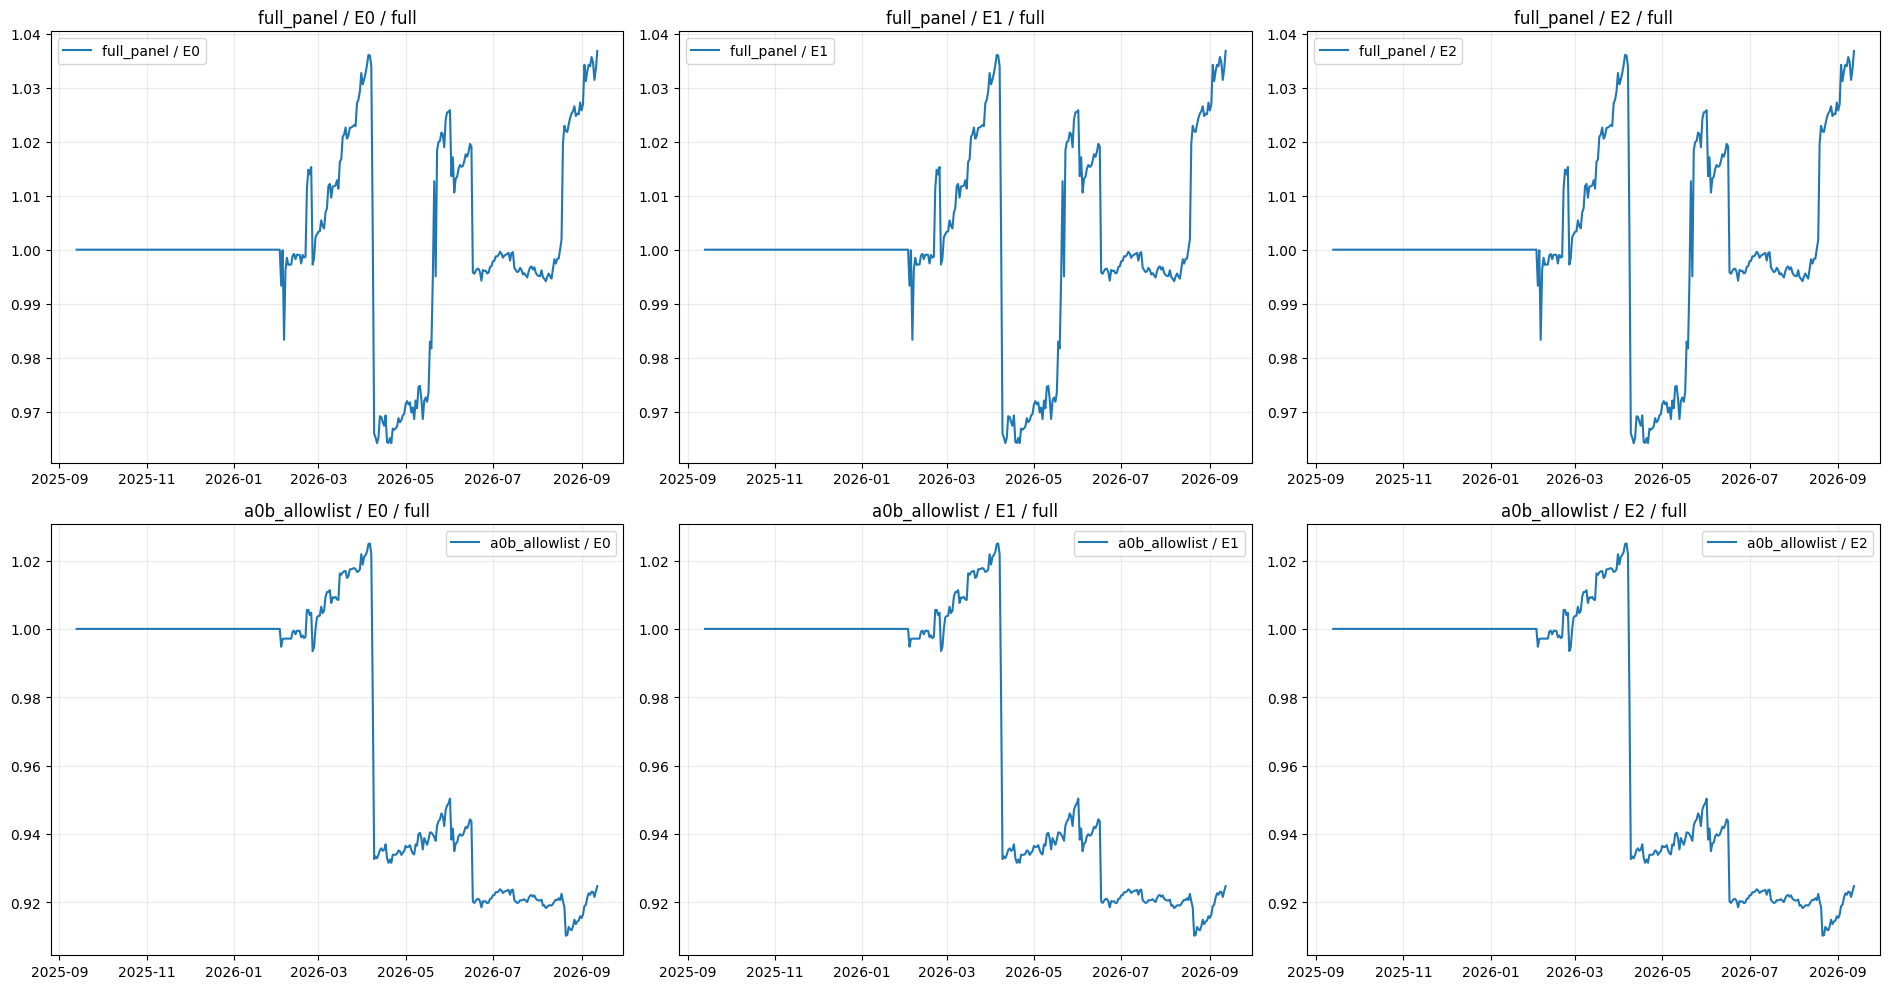

In [5]:
cap_rows = []
stratwise_rows = []
for (universe_name, arm, period_name), targets in TARGETS.items():
    if len(targets):
        provisional = targets[targets.provisional]
        accepted_provisional = provisional.accepted_dollars.sum()
        max_sleeve = INITIAL_CASH * PROVISIONAL_SLEEVE
        cap_rows.append({
            "universe": universe_name, "arm": arm, "period": period_name,
            "target_rows": len(targets), "provisional_rows": len(provisional),
            "individual_cap_binding_rows": int(targets.individual_cap_binding.sum()),
            "aggregate_cap_binding_rows": int(targets.aggregate_provisional_cap_binding.sum()),
            "mean_requested_dollars": float(targets.requested_dollars.mean()),
            "mean_accepted_dollars": float(targets.accepted_dollars.mean()),
            "max_provisional_accepted_dollars": float(accepted_provisional),
            "max_daily_provisional_accepted_dollars": float(provisional.groupby("date").accepted_dollars.sum().max()),
            "initial_cash_sleeve_cap_dollars": max_sleeve,
        })
        if (targets.accepted_dollars > targets.cap_dollars + 1e-6).any():
            raise AssertionError("individual or TVL cap breached")
        daily_provisional = provisional.groupby("date").accepted_dollars.sum()
        if (daily_provisional > INITIAL_CASH * PROVISIONAL_SLEEVE + 1e-6).any():
            raise AssertionError("aggregate provisional sleeve cap breached")
    curve = CURVES[(universe_name, arm, period_name)]
    stratwise_targets = targets[targets.address.eq(STRATWISE)] if len(targets) else targets
    stratwise_rows.append({
        "universe": universe_name, "arm": arm, "period": period_name,
        "target_rows": len(stratwise_targets), "selected_dates": int(stratwise_targets.date.nunique()) if len(stratwise_targets) else 0,
        "accepted_days": int((stratwise_targets.accepted_dollars > 0).sum()) if len(stratwise_targets) else 0,
        "mean_accepted_weight": float(stratwise_targets.accepted_weight.mean()) if len(stratwise_targets) else np.nan,
        "provisional_days": int(stratwise_targets.provisional.sum()) if len(stratwise_targets) else 0,
        "period_start": curve.date.iloc[0], "period_end": curve.date.iloc[-1],
    })

cap_summary = pd.DataFrame(cap_rows)
stratwise_coverage = pd.DataFrame(stratwise_rows)
cap_summary.to_csv(OUT / "cap-and-opportunity-cost.csv", index=False)
stratwise_coverage.to_csv(OUT / "stratwise-coverage.csv", index=False)
display(cap_summary.round(4))
display(stratwise_coverage)

fig, axes = plt.subplots(2, 3, figsize=(19, 10), sharex=False)
for axis, (universe_name, arm) in zip(axes.flat, [(u, a) for u in SELECTIONS for a in ARMS]):
    curve = CURVES[(universe_name, arm, "full")]
    axis.plot(curve.date, curve.equity / curve.equity.iloc[0], label=f"{universe_name} / {arm}")
    axis.set_title(f"{universe_name} / {arm} / full")
    axis.grid(alpha=.25)
    axis.legend()
fig.tight_layout()
fig.savefig(OUT / "young-sparse-equity-curves.png", dpi=130)
plt.show()


In [6]:
report = {
    "notebook": "14-research-young-and-sparse-evidence.ipynb",
    "parent": "NB12 P1+D1 frozen selection; no forward labels loaded",
    "arms": list(ARMS),
    "evidence_policy": {
        "provisional": "available history <30d, fewer than four measured weekly outcomes, sparse cadence, or missing growth/downside/consistency evidence",
        "E0": "5% individual provisional cap and 20% aggregate provisional sleeve",
        "E1": "2% individual provisional cap and 20% aggregate provisional sleeve",
        "E2": "2% to 10% individual cap over 2 to 20 observed intervals and 20% aggregate provisional sleeve",
    },
    "periods": {name: [str(start.date()), str(end.date())] for name, (start, end) in PERIODS.items()},
    "starting_cash": INITIAL_CASH,
    "target_deployment": TARGET_DEPLOYMENT,
    "individual_mature_cap": MAX_WEIGHT,
    "tvl_cap_fraction": MAX_TVL_FRACTION,
    "aggregate_provisional_sleeve": PROVISIONAL_SLEEVE,
    "execution_every_days": EXECUTION_EVERY_DAYS,
    "point_in_time_risk_signals": {
        "rows": int(len(POINT_IN_TIME)),
        "dates": [str(POINT_IN_TIME.date.min().date()), str(POINT_IN_TIME.date.max().date())],
        "addresses": int(POINT_IN_TIME.address.nunique()),
    },
    "fees": "none added; observable NAV share prices are the accounting input",
    "marks": "fresh raw share-price observations forward-filled for valuation only",
    "weekly_metrics": "sampled from completed daily equity curves and never used for preceding decisions",
    "universe_warning": "A0b allowlist is a retrospective current snapshot; full panel is a sensitivity",
    "stratwise_address": STRATWISE,
    "metrics": metrics_table.to_dict(orient="records"),
    "evidence_summary": evidence_summary.to_dict(orient="records"),
    "age_cadence_summary": age_cadence_summary.to_dict(orient="records"),
    "stratwise_coverage": stratwise_coverage.to_dict(orient="records"),
}
(OUT / "nb14-report.json").write_text(json.dumps(report, indent=2, default=str))
print({"report": str(OUT / "nb14-report.json"), "metrics_rows": len(metrics_table), "stratwise_rows": len(stratwise_coverage)})


{'report': '/Users/moo/code/getting-started/scratchpad/hyperliquid-ic/_artifacts-young-sparse/nb14-report.json', 'metrics_rows': 12, 'stratwise_rows': 12}
